### Business Problem

This project aims to analyze transactional data from an e-commerce business in order to uncover insights that can help improve revenue, customer retention, and overall business performance.

E-commerce companies generate large volumes of data, but without proper analysis, it is difficult to understand customer behavior, identify high-performing products, and make data-driven decisions.

---

### Business Objectives

The main objectives of this analysis are:

- Identify the most profitable products and categories
- Understand customer purchasing behavior
- Detect patterns and trends in sales over time
- Segment customers based on their value to the business
- Provide actionable recommendations to increase revenue and customer retention

---

### Analytical Approach

To achieve these objectives, the following steps will be performed:

1. Data Cleaning and preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Product Analysis
5. Customer Segmentation (RFM)
6. Business Insights and recommendations
7. API integration for extended analysis

---
### Expected Outcome

The final result of this project will be a set of data-driven insights and recommendations that can help the business optimize sales strategies, improve customer retention, and maximize profitability.

In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lakshmi25npathi/online-retail-dataset/online_retail_II.xlsx


In [26]:
df = pd.read_excel('/kaggle/input/datasets/lakshmi25npathi/online-retail-dataset/online_retail_II.xlsx')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [28]:
df.shape

(525461, 8)

In [29]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


## 🧹 Data Cleaning

Before starting the analysis, the dataset was cleaned to ensure data quality and reliability.

### Steps performed:

- A copy of the original dataset was created to preserve the raw data
- Rows with negative or zero values in **Quantity** and **Price** were removed, as they do not represent valid transactions
- Missing values in the **Customer ID** column were removed, since customer-based analysis requires valid customer information
- Duplicate records were removed to avoid double counting
- The **InvoiceDate** column was converted to datetime format for time-based analysis
- A new column **Revenue** was created by multiplying Quantity and Price


In [30]:
df_raw = df.copy()

df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

df = df.dropna(subset=['Customer ID'])

df = df.drop_duplicates()

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Revenue'] = df['Quantity'] * df['Price']

print(f"Original number of records: {df_raw.shape[0]}")
print(f"Cleaned number of records: {df.shape[0]}")

df.head()

Original number of records: 525461
Cleaned number of records: 400916


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


### Result:

The dataset is now cleaned and ready for further analysis, ensuring that only valid and meaningful transactions are included.

## 📊 Exploratory Data Analysis (EDA)

In this section, we explore the dataset to uncover patterns, trends, and key insights that can help understand business performance.

The goal is to analyze revenue distribution, sales trends over time, and product performance.

### Revenue by Country (Initial Overview)

To understand how revenue is distributed across different countries, we first calculate the total revenue generated by each country.

This will help us identify the top-performing markets and see whether the business depends on specific regions.

In [31]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

print("Top 10 Countries by Revenue:")
print(country_revenue.head(10))

Top 10 Countries by Revenue:
Country
United Kingdom    7381644.433
EIRE               356041.860
Netherlands        268784.350
Germany            202025.391
France             146107.070
Sweden              53147.990
Denmark             50906.850
Spain               47568.650
Switzerland         43921.390
Australia           31446.800
Name: Revenue, dtype: float64


### Focus on International Markets

From the results above, we can observe that the United Kingdom generates significantly higher revenue compared to other countries.

To better understand the performance of other markets, we will exclude the United Kingdom and visualize the top 10 remaining countries.

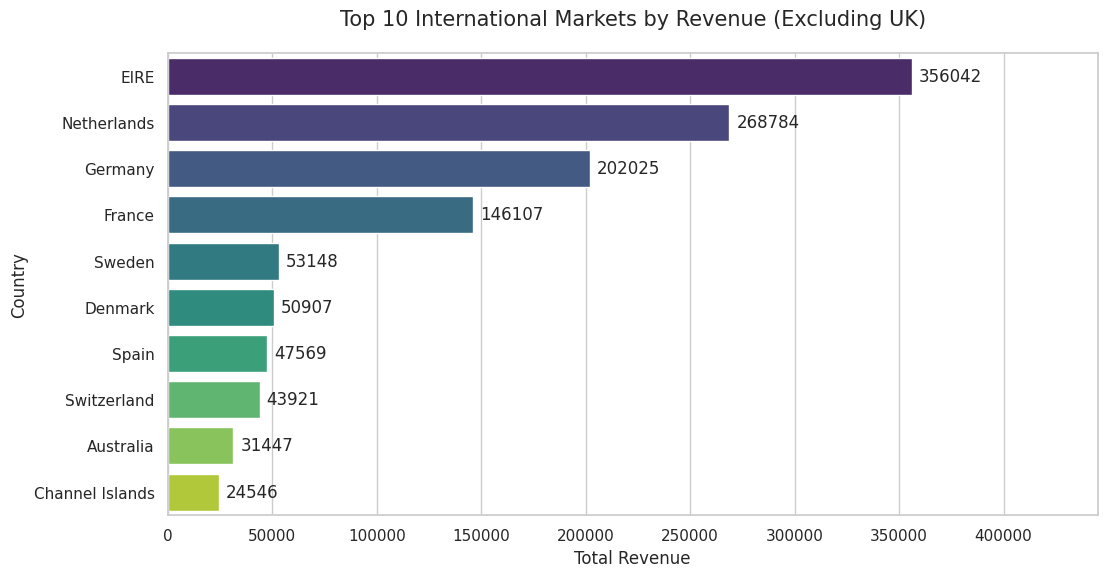

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

top10_df = country_revenue.iloc[1:11].reset_index()
top10_df.columns = ["Country", "Revenue"]

plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

ax = sns.barplot(
    data=top10_df, 
    x="Revenue", 
    y="Country", 
    hue="Country", 
    palette="viridis", 
    legend=False
)
for i in ax.containers:
    ax.bar_label(i, fmt='%.0f', padding=5)

plt.xlim(0, top10_df['Revenue'].max() * 1.25)
plt.title('Top 10 International Markets by Revenue (Excluding UK)', fontsize=15, pad=20)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.show()

### Insight:
The United Kingdom dominates overall revenue, so it was excluded from the visualization to better highlight the performance of other international markets.

Among the remaining countries, a small group contributes the majority of revenue, indicating potential key markets for expansion.

### Revenue Trend Over Time

After analyzing the geographical distribution of revenue, it is important to examine how revenue evolves over time.

This analysis helps identify trends, seasonality patterns, and periods of growth or decline in the business performance.

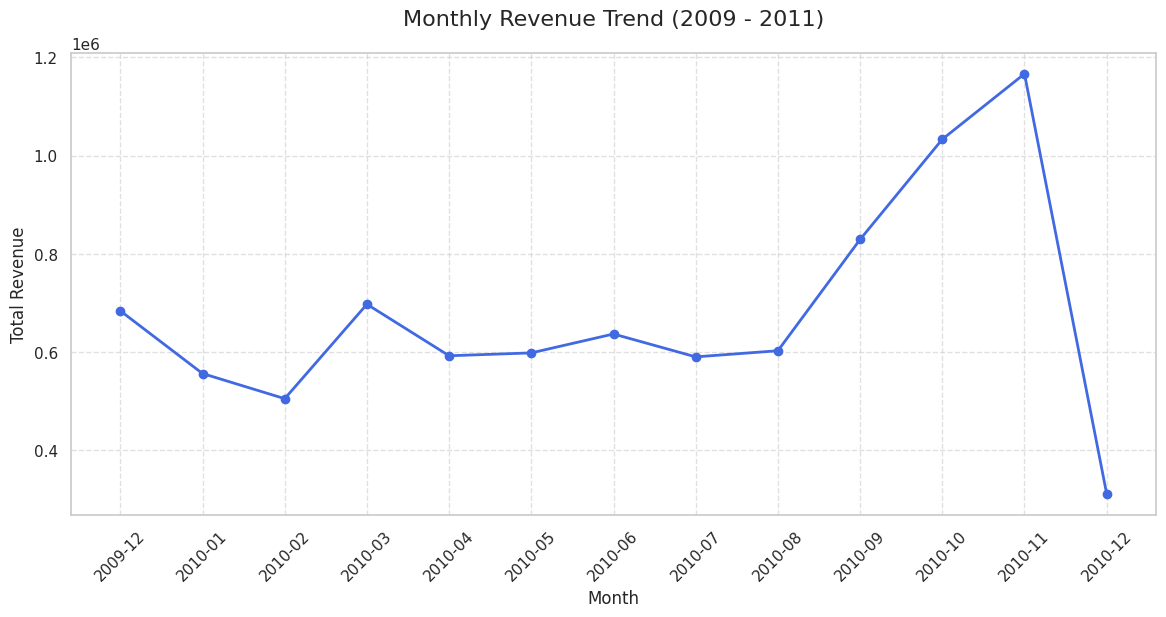

In [33]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Month_Year'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month_Year')['Revenue'].sum().reset_index()

monthly_sales['Month_Year'] = monthly_sales['Month_Year'].astype(str)

plt.figure(figsize=(14, 6))

plt.plot(monthly_sales['Month_Year'], monthly_sales['Revenue'], marker='o', linestyle='-', color='royalblue', linewidth=2)
plt.title('Monthly Revenue Trend (2009 - 2011)', fontsize=16, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Insight:
The revenue shows noticeable fluctuations over time, indicating periods of higher and lower sales activity.

There may be seasonal patterns, with certain months generating higher revenue, which could be linked to holidays or promotional periods.

Understanding these trends can help the business better plan marketing strategies and inventory management.

### Best-Selling Products

To understand product performance, we analyze which products are sold in the highest quantities.

This helps identify popular items and products that drive sales volume.

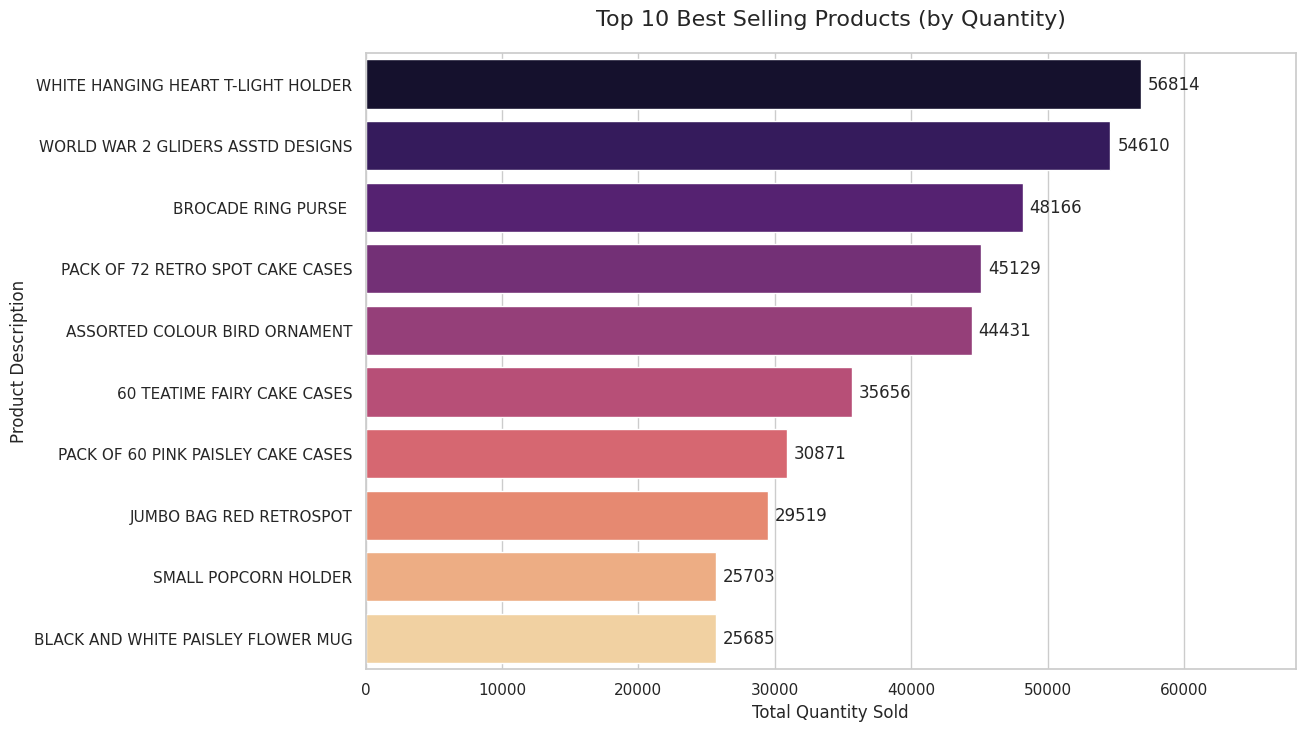

In [34]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=top_products, 
    x="Quantity", 
    y="Description", 
    hue="Description",
    palette="magma", 
    legend=False
)

for i in ax.containers:
    ax.bar_label(i, fmt='%.0f', padding=5)

plt.title('Top 10 Best Selling Products (by Quantity)', fontsize=16, pad=20)
plt.xlabel('Total Quantity Sold', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.xlim(0, top_products['Quantity'].max() * 1.2)
plt.show()

### Insight:
Sales volume is concentrated in a small number of products, suggesting that the business relies on a few highly popular items.

These products are likely essential for maintaining consistent sales and should be carefully managed in terms of stock and availability.

## ⚙️ Feature Engineering

In this step, new features are created from the existing data to enhance the analysis.

These features will help better understand customer behavior, purchasing patterns, and overall business performance.

In [35]:
orders_per_customer = df.groupby('Customer ID')['Invoice'].nunique().reset_index()
orders_per_customer.columns = ['CustomerID', 'TotalOrders']
orders_per_customer

,CustomerID,TotalOrders
0,12346.0,11
1,12347.0,2
2,12348.0,1
3,12349.0,3
4,12351.0,1
...,...,...
4307,18283.0,6
4308,18284.0,1
4309,18285.0,1
4310,18286.0,2


In [36]:
revenue_per_customer = df.groupby('Customer ID')['Revenue'].sum().reset_index()
revenue_per_customer.columns = ['CustomerID', 'TotalRevenue']
revenue_per_customer

,CustomerID,TotalRevenue
0,12346.0,372.86
1,12347.0,1323.32
2,12348.0,222.16
3,12349.0,2671.14
4,12351.0,300.93
...,...,...
4307,18283.0,619.37
4308,18284.0,461.68
4309,18285.0,427.00
4310,18286.0,1296.43


In [37]:
customer_df = pd.merge(orders_per_customer, revenue_per_customer, on = 'CustomerID')
customer_df

,CustomerID,TotalOrders,TotalRevenue
0,12346.0,11,372.86
1,12347.0,2,1323.32
2,12348.0,1,222.16
3,12349.0,3,2671.14
4,12351.0,1,300.93
...,...,...,...
4307,18283.0,6,619.37
4308,18284.0,1,461.68
4309,18285.0,1,427.00
4310,18286.0,2,1296.43


In [38]:
customer_df['AvgOrderValue'] = customer_df['TotalRevenue'] / customer_df['TotalOrders']
customer_df

,CustomerID,TotalOrders,TotalRevenue,AvgOrderValue
0,12346.0,11,372.86,33.896364
1,12347.0,2,1323.32,661.660000
2,12348.0,1,222.16,222.160000
3,12349.0,3,2671.14,890.380000
4,12351.0,1,300.93,300.930000
...,...,...,...,...
4307,18283.0,6,619.37,103.228333
4308,18284.0,1,461.68,461.680000
4309,18285.0,1,427.00,427.000000
4310,18286.0,2,1296.43,648.215000


In [39]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days = 1)
recency_df = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
recency_df['Recency'] = (snapshot_date - recency_df['InvoiceDate']).dt.days

customer_df = pd.merge(customer_df, recency_df[['Customer ID', 'Recency']],
                      left_on = 'CustomerID', right_on = 'Customer ID').drop('Customer ID', axis=1)

customer_df.head()

,CustomerID,TotalOrders,TotalRevenue,AvgOrderValue,Recency
0,12346.0,11,372.86,33.896364,165
1,12347.0,2,1323.32,661.660000,3
2,12348.0,1,222.16,222.160000,74
3,12349.0,3,2671.14,890.380000,43
4,12351.0,1,300.93,300.930000,11


### Feature Engineering Summary

New customer-level features were created to better understand purchasing behavior:

- Total number of orders per customer  
- Total revenue generated by each customer  
- Average order value  
- Recency (number of days since the customer's last purchase)

These features provide a more complete view of customer behavior by combining purchase frequency, spending patterns, and recency of activity.

They will be used in the next steps to identify high-value customers, detect potentially inactive customers, and support data-driven business decisions.

## 🛍️ Product Analysis

In this section, we analyze product performance to identify which items contribute most to the business revenue.

Understanding top-performing products helps the business optimize inventory, pricing strategies, and marketing efforts.

### Comparing Product Performance

To gain deeper insights into product performance, we compare the top products based on revenue and quantity sold.

This helps identify whether the most sold products are also the most profitable, or if there are differences between sales volume and revenue generation.

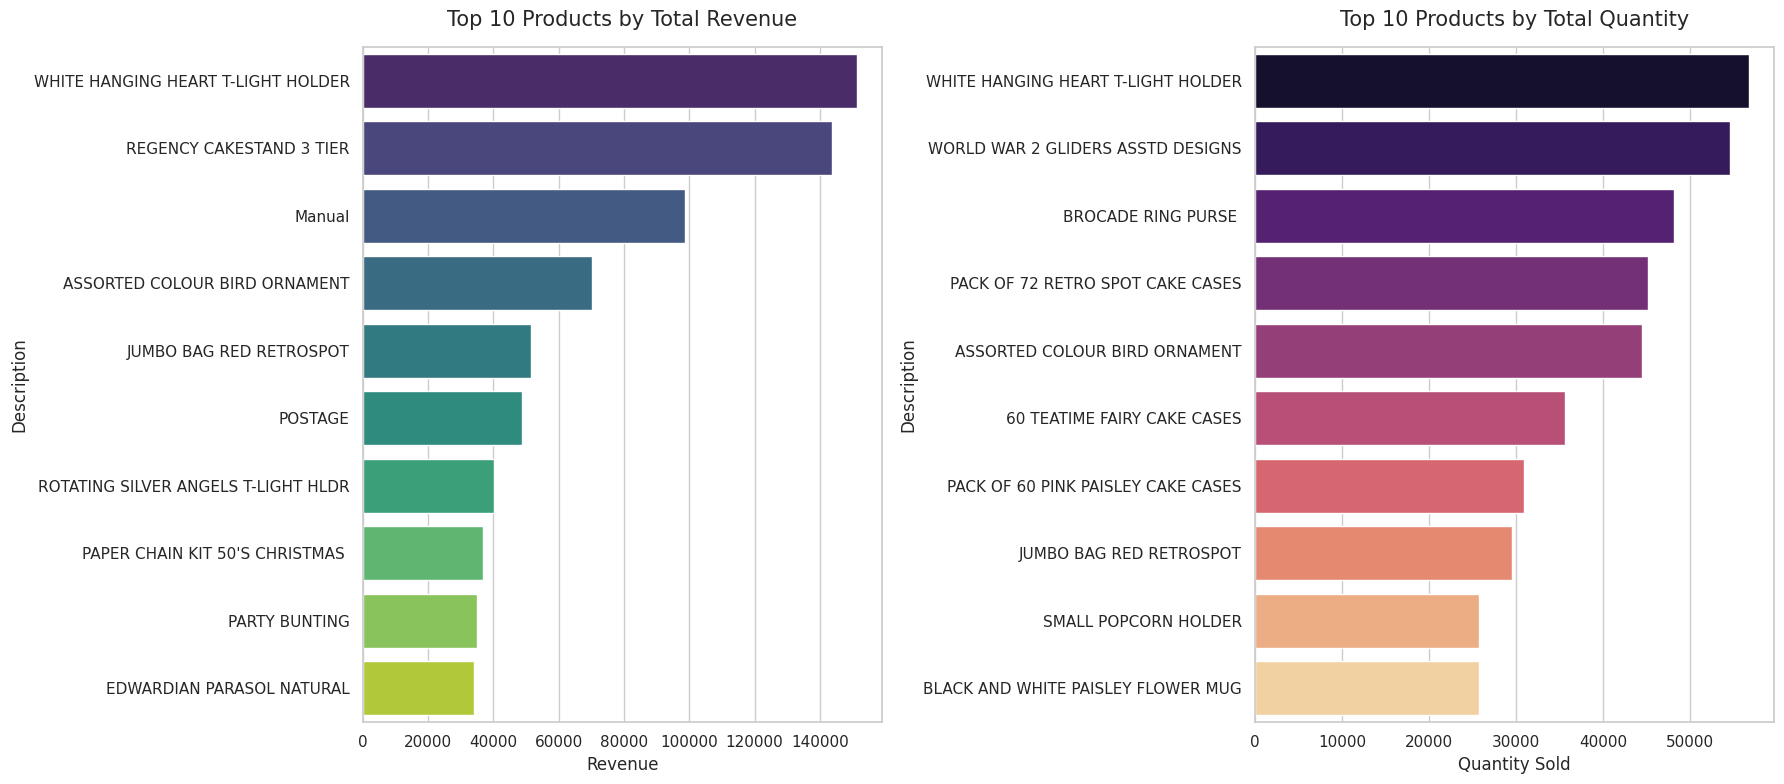

In [40]:
top10_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()
top10_quantity = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10).reset_index()



fig, ax = plt.subplots(1, 2, figsize = (18, 8))

sns.barplot(
    data = top10_revenue, 
    x = 'Revenue', 
    y = 'Description', 
    hue = 'Description',
    palette = 'viridis', 
    ax = ax[0], 
    legend = False
)
ax[0].set_title('Top 10 Products by Total Revenue', fontsize = 15, pad=15)
ax[0].set_xlabel('Revenue')
ax[0].set_ylabel('Description')

sns.barplot(
    data = top10_quantity, 
    x = 'Quantity', 
    y = 'Description', 
    hue = 'Description',
    palette = 'magma', 
    ax = ax[1], 
    legend = False
)
ax[1].set_title('Top 10 Products by Total Quantity', fontsize = 15, pad=15)
ax[1].set_xlabel('Quantity Sold')
ax[1].set_ylabel('Description')

plt.tight_layout()
plt.show()

### Insight:

There is a noticeable difference between the most sold products and the most profitable ones.

Some products generate high revenue despite lower sales volume, likely due to higher prices.  
Others are sold frequently but contribute less to total revenue.

This suggests that both pricing and sales volume play an important role in overall business performance.

### Revenue and Market Distribution by Country

To better understand international market performance, we analyze both revenue and transaction distribution across countries (excluding the United Kingdom).

This helps identify key markets and compare their contribution to overall business activity.

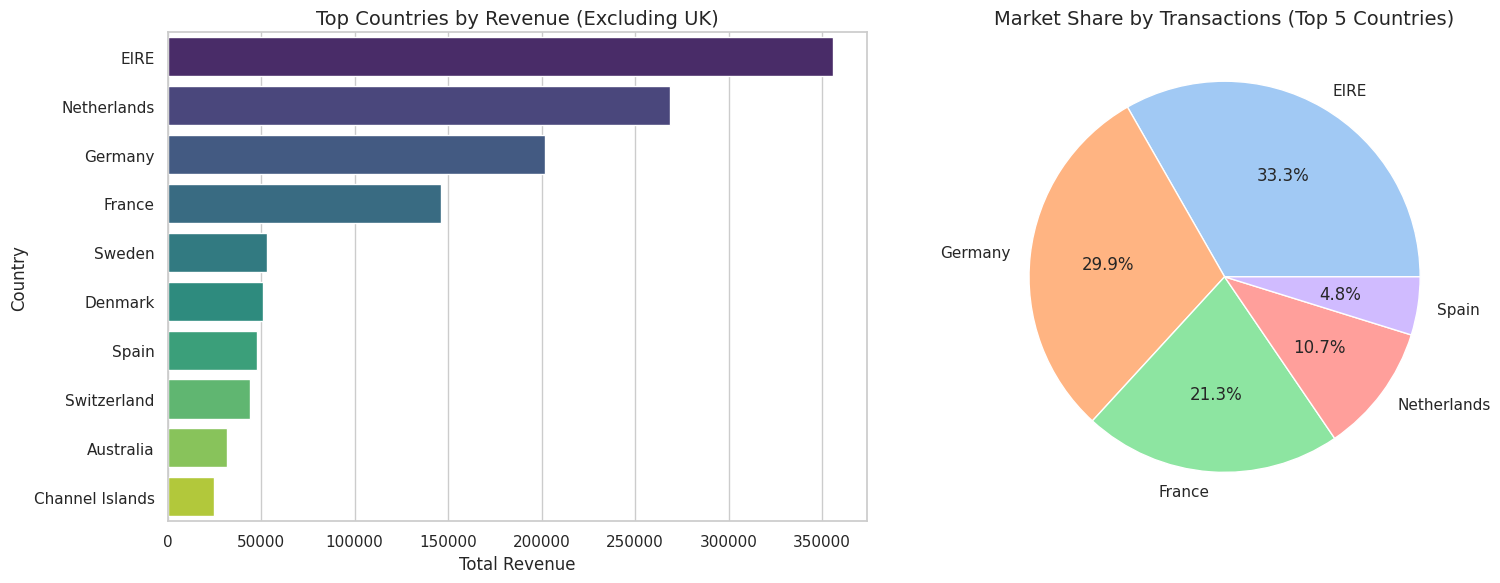

In [41]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).reset_index()
country_revenue_no_uk = country_revenue[country_revenue['Country'] != 'United Kingdom'].head(10)

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.barplot(
    data=country_revenue_no_uk, 
    x='Revenue', 
    y='Country', 
    hue='Country', 
    palette='viridis', 
    legend=False)
plt.title('Top Countries by Revenue (Excluding UK)', fontsize=14)
plt.xlabel('Total Revenue')

plt.subplot(1, 2, 2)
country_counts = df[df['Country'] != 'United Kingdom']['Country'].value_counts().head(5)
plt.pie(
    country_counts, 
    labels=country_counts.index, 
    autopct='%1.1f%%', 
    colors=sns.color_palette('pastel'))
plt.title('Market Share by Transactions (Top 5 Countries)', fontsize=14)

plt.tight_layout()
plt.show()

### Insight:
Revenue and transaction distribution show that a small number of countries dominate international sales.

Some countries generate higher revenue, while others have a higher share of transactions, indicating differences in purchasing behavior across markets.

This suggests opportunities for targeted strategies in specific regions.

### Top Products by Country

To better understand customer preferences across different markets, we analyze the top-selling products in selected countries.

This helps identify differences in demand and highlights how product popularity varies by region.

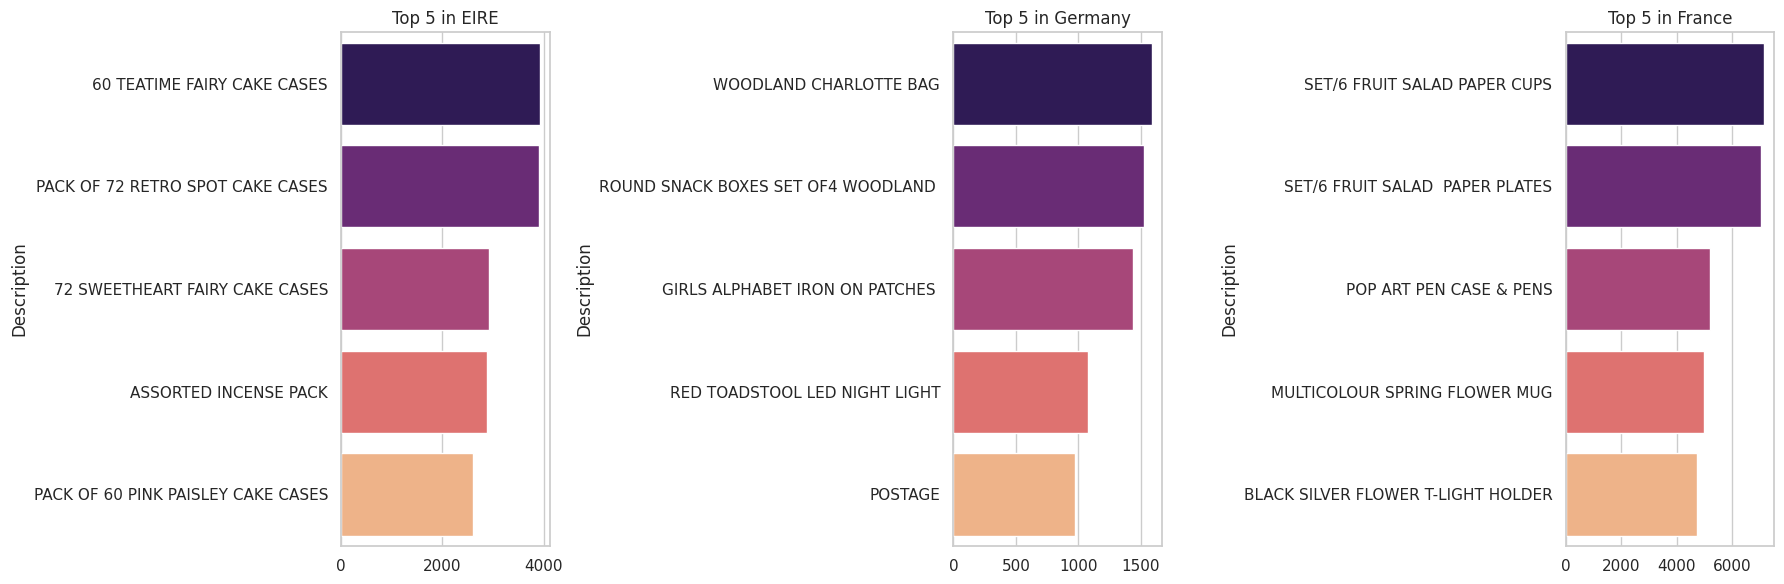

In [42]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

top_eire = df[df['Country'] == 'EIRE'].groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5)
sns.barplot(
    x=top_eire.values, 
    y=top_eire.index, 
    ax=ax[0], 
    palette='magma', 
    hue=top_eire.index, 
    legend=False)
ax[0].set_title('Top 5 in EIRE')

top_germany = df[df['Country'] == 'Germany'].groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5)
sns.barplot(
    x=top_germany.values, 
    y=top_germany.index, 
    ax=ax[1], 
    palette='magma', 
    hue=top_germany.index, 
    legend=False)
ax[1].set_title('Top 5 in Germany')

top_france = df[df['Country'] == 'France'].groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5)
sns.barplot(
    x=top_france.values, 
    y=top_france.index, 
    ax=ax[2], 
    palette='magma', 
    hue=top_france.index, 
    legend=False)
ax[2].set_title('Top 5 in France')

plt.tight_layout()
plt.show()

### Insight:
Product preferences vary between countries, as different items appear among the top-selling products in each market.

This indicates that customer behavior is not uniform across regions and suggests the need for localized product strategies.

## 👥 Customer Segmentation

In this section, we analyze customer behavior to better understand how customers interact with the business.

The analysis focuses on:
- How recently customers have made a purchase (Recency)  
- How often they purchase (Frequency)  
- How much they spend (Monetary value)  

This helps identify valuable customers, loyal customers, and those who may need re-engagement.

### Top Customers by Revenue

To identify the most valuable customers, we analyze those who generate the highest total revenue.

In [43]:
top_customers = customer_df.sort_values(by = 'TotalRevenue', ascending = False).head(10)
top_customers

,CustomerID,TotalOrders,TotalRevenue,AvgOrderValue,Recency
4183,18102.0,89,349164.35,3923.194944,1
1637,14646.0,78,248396.50,3184.570513,10
1269,14156.0,102,196549.74,1926.958235,7
1840,14911.0,205,152121.22,742.054732,1
939,13694.0,94,131443.19,1398.331809,9
3744,17511.0,31,84541.17,2727.134516,3
1951,15061.0,86,83284.38,968.423023,3
3128,16684.0,27,80489.21,2981.081852,15
3177,16754.0,29,65500.07,2258.623103,8
4065,17949.0,74,60117.60,812.400000,7


### Insight:
A small group of customers generates a significant portion of total revenue.

These customers are highly valuable to the business and should be prioritized in retention and loyalty strategies.

### Customer Activity (Recency)

To understand customer engagement, we analyze how recently customers have made a purchase.

In [44]:
customer_df['Recency'].describe()

count    4312.000000
mean       91.171846
std        96.860633
min         1.000000
25%        18.000000
50%        53.000000
75%       136.000000
max       374.000000
Name: Recency, dtype: float64

### Insight:
Customers with lower Recency values are more active and engaged.

Customers with higher Recency values may be at risk of not returning and could require targeted marketing efforts.

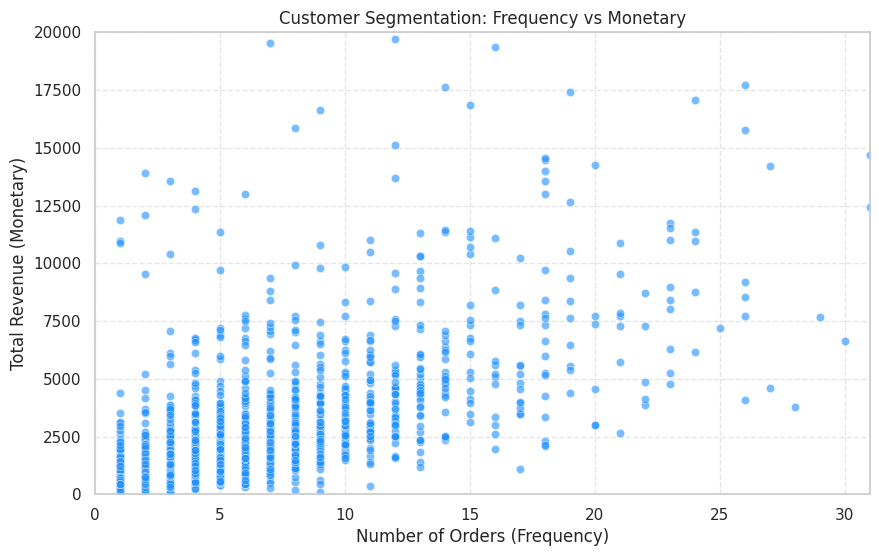

In [45]:
plt.figure(figsize = (10, 6))
sns.scatterplot(
    data = customer_df,
    x = 'TotalOrders',
    y = 'TotalRevenue',
    alpha = 0.6,
    color='dodgerblue'
)
plt.title('Customer Segmentation: Frequency vs Monetary')
plt.xlabel('Number of Orders (Frequency)') 
plt.ylabel('Total Revenue (Monetary)')

plt.xlim(0, customer_df['TotalOrders'].quantile(0.99))
plt.ylim(0, customer_df['TotalRevenue'].quantile(0.99))
plt.grid(True, linestyle = '--', alpha = 0.5)

plt.show()

### Insight:
Most customers generate relatively low revenue and place a small number of orders.

A smaller group of customers shows higher frequency and spending, indicating more valuable and engaged customers.

In [46]:
def simple_segmenter(days):
    if days <= 30:
        return 'Active'
    elif days <= 90:
        return 'At Risk'
    else:
        return 'Churned'

customer_df['Status'] = customer_df['Recency'].apply(simple_segmenter)
print(customer_df['Status'].value_counts())

Status
Active     1569
Churned    1435
At Risk    1308
Name: count, dtype: int64


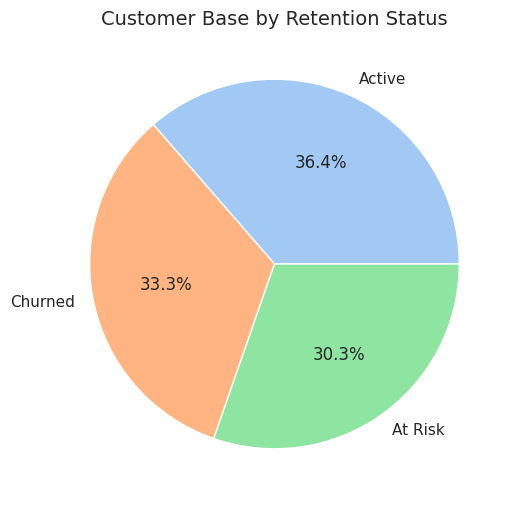

In [47]:
status_counts = customer_df['Status'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(status_counts, 
        labels=status_counts.index,
        autopct='%1.1f%%',              
        colors=sns.color_palette('pastel')
       ) 
plt.title('Customer Base by Retention Status', fontsize=14)
plt.show()

### Insight:
Customers can be divided into active, at-risk, and churned groups based on their recent activity.

A significant number of customers may fall into the at-risk or churned categories, indicating potential opportunities for re-engagement strategies.

## 📌 Conclusion & Business Insights

Based on the analysis, several key insights and actionable recommendations can be made to improve business performance.

### Key Business Insights & Recommendations

- **Focus on top-performing products**  
A small number of products generate a large share of revenue. Increasing their visibility and ensuring availability can boost sales.

- **Strengthen international markets**  
Revenue is highly concentrated in the United Kingdom. Expanding marketing efforts in other countries could increase overall growth.

- **Retain high-value customers**  
A small group of customers contributes significantly to total revenue. Loyalty programs and personalized offers can help retain them.

- **Re-engage inactive customers**  
Customers classified as “At Risk” or “Churned” should be targeted with campaigns, discounts, or reminders to return.

- **Adapt strategy by region**  
Product preferences differ across countries, suggesting the need for localized marketing and product selection.

## 🔌 API Integration

To enhance the analysis, we demonstrate how external data can be integrated using an API.

This allows for real-time data updates and automation of insights.

In [48]:
import requests

url = "https://api.exchangerate-api.com/v4/latest/GBP"
response = requests.get(url)
data = response.json()

print("Exchange rates (GBP):")
print(data['rates'])

Exchange rates (GBP):
{'GBP': 1, 'AED': 4.85, 'AFN': 84.55, 'ALL': 110.64, 'AMD': 501.12, 'ANG': 2.36, 'AOA': 1245.64, 'ARS': 1840.86, 'AUD': 1.93, 'AWG': 2.36, 'AZN': 2.25, 'BAM': 2.25, 'BBD': 2.64, 'BDT': 162.29, 'BGN': 2.25, 'BHD': 0.496, 'BIF': 3956.08, 'BMD': 1.32, 'BND': 1.7, 'BOB': 9.18, 'BRL': 6.92, 'BSD': 1.32, 'BTN': 124.81, 'BWP': 18.87, 'BYN': 3.93, 'BZD': 2.64, 'CAD': 1.84, 'CDF': 3063.73, 'CHF': 1.06, 'CLF': 0.0309, 'CLP': 1222.53, 'CNH': 9.12, 'CNY': 9.13, 'COP': 4857, 'CRC': 616.45, 'CUP': 31.67, 'CVE': 126.88, 'CZK': 28.25, 'DJF': 234.54, 'DKK': 8.59, 'DOP': 78.92, 'DZD': 176.61, 'EGP': 71.87, 'ERN': 19.8, 'ETB': 208.43, 'EUR': 1.15, 'FJD': 2.96, 'FKP': 1, 'FOK': 8.59, 'GEL': 3.57, 'GGP': 1, 'GHS': 14.57, 'GIP': 1, 'GMD': 98.09, 'GNF': 11596.15, 'GTQ': 10.15, 'GYD': 277.76, 'HKD': 10.33, 'HNL': 35.19, 'HRK': 8.67, 'HTG': 174.21, 'HUF': 447.13, 'IDR': 22438.4, 'ILS': 4.18, 'IMP': 1, 'INR': 124.81, 'IQD': 1741.35, 'IRR': 1012834.93, 'ISK': 165.26, 'JEP': 1, 'JMD': 208.92

### Insight:
Using APIs allows businesses to access real-time external data, such as exchange rates, which can support better decision-making and dynamic pricing strategies.